The model learns what “normal” looks like and flags events that:
Spike in cancel/new ratio
Have unusual spread or volume imbalance
Show rare mid-price jumps

These are potentially:
Spoofing
Quote stuffing
Outlier market behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('/Users/manika/Desktop/Python : Learning/market-microstructure-analyzer/data/df_featured.csv')

In [3]:
#selecting features

feature_cols = ['mid_price_diff', 'spread', 'volume_imbalance', 'cancel_new_50']
X = df[feature_cols].copy()


In [4]:
# Feature Scaling (very important for anomaly models)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Train Isolation Forest
model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42)
model.fit(X_scaled)

# Predict anomalies
df['anomaly_score'] = model.decision_function(X_scaled)
df['anomaly'] = model.predict(X_scaled)

# Interpretation:
# -1 = anomaly
# 1 = normal
# anomaly_score = confidence

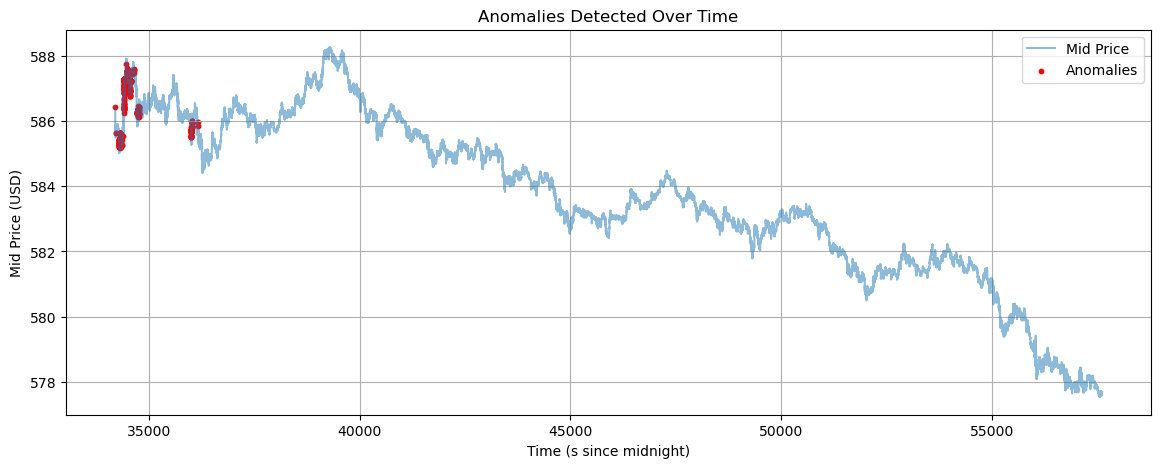

In [ ]:
anomalies = df[df['anomaly'] == -1]

plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['mid_price'], label='Mid Price', alpha=0.5)
plt.scatter(anomalies['time'], anomalies['mid_price'], color='red', label='Anomalies', s=10)
plt.legend()
plt.title('Anomalies Detected - Isolation Forest')
plt.xlabel('Time (s since midnight)')
plt.ylabel('Mid Price (USD)')
plt.grid(True)
plt.show()


Investigating the anomalies

In [7]:
a_date = df[df['anomaly'] == -1]['datetime']


In [8]:
df_anomaly = df[(df['datetime'].isin(a_date)) & (df['anomaly'] == -1)]
df_anomaly = df_anomaly[[
    'datetime', 'order_id', 'type', 'price', 'size', 'direction',
    'spread', 'cancel_new_50', 'volume_imbalance', 'mid_price'
]].sort_values('datetime')

In [9]:
df_anomaly

,datetime,order_id,type,price,size,direction,spread,cancel_new_50,volume_imbalance,mid_price
20,2024-01-01 09:30:00.394048,16207170,1,5859900,100,-1,0.96,0.0,-0.000157,586.410
453,2024-01-01 09:30:15.222997,17172314,1,5854300,251,-1,0.38,0.0,-0.000108,585.620
484,2024-01-01 09:30:19.517076,17329817,1,5854400,44,-1,0.37,0.0,-0.000109,585.625
1856,2024-01-01 09:31:26.984243,19260106,1,5852600,13,-1,0.39,0.0,-0.000105,585.455
2061,2024-01-01 09:31:28.725310,19300154,1,5850100,50,-1,0.53,0.0,-0.000101,585.275
...,...,...,...,...,...,...,...,...,...,...
36486,2024-01-01 10:00:16.006448,47795755,1,5855500,44,-1,0.45,0.0,-0.000071,585.775
36754,2024-01-01 10:00:26.138094,48090771,3,5859400,100,-1,0.43,0.0,-0.000101,586.005
36795,2024-01-01 10:00:26.674847,48175505,3,5858500,18,-1,0.43,0.0,-0.000104,586.005
41482,2024-01-01 10:02:42.371857,50451083,3,5860300,100,-1,0.60,0.0,-0.000080,585.950


In [10]:
def compare_anomaly_vs_normal(ts_anomaly, ts_normal=None, window=1.0):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # ---- Plot 1: Anomaly ----
    ts_float = df[df['datetime'] == ts_anomaly]['time'].iloc[0]
    mask = (df['time'] >= ts_float - window) & (df['time'] <= ts_float + window)
    axs[0].plot(df[mask]['time'], df[mask]['mid_price'], label='Mid Price', alpha=0.6)
    axs[0].scatter(df[(mask) & (df['anomaly'] == -1)]['time'],
                   df[(mask) & (df['anomaly'] == -1)]['mid_price'],
                   color='red', label='Anomaly', s=30)
    axs[0].set_title(f"Anomaly Window\n{ts_anomaly}")
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Mid Price (USD)")
    axs[0].legend()
    axs[0].grid(True)

    # ---- Plot 2: Normal (optional) ----
    if ts_normal:
        ts_float_n = df[df['datetime'] == ts_normal]['time'].iloc[0]
        mask_n = (df['time'] >= ts_float_n - window) & (df['time'] <= ts_float_n + window)
        axs[1].plot(df[mask_n]['time'], df[mask_n]['mid_price'], label='Mid Price', alpha=0.6)
        axs[1].set_title(f"Normal Window\n{ts_normal}")
        axs[1].set_xlabel("Time (s)")
        axs[1].grid(True)

    plt.tight_layout()
    plt.show()


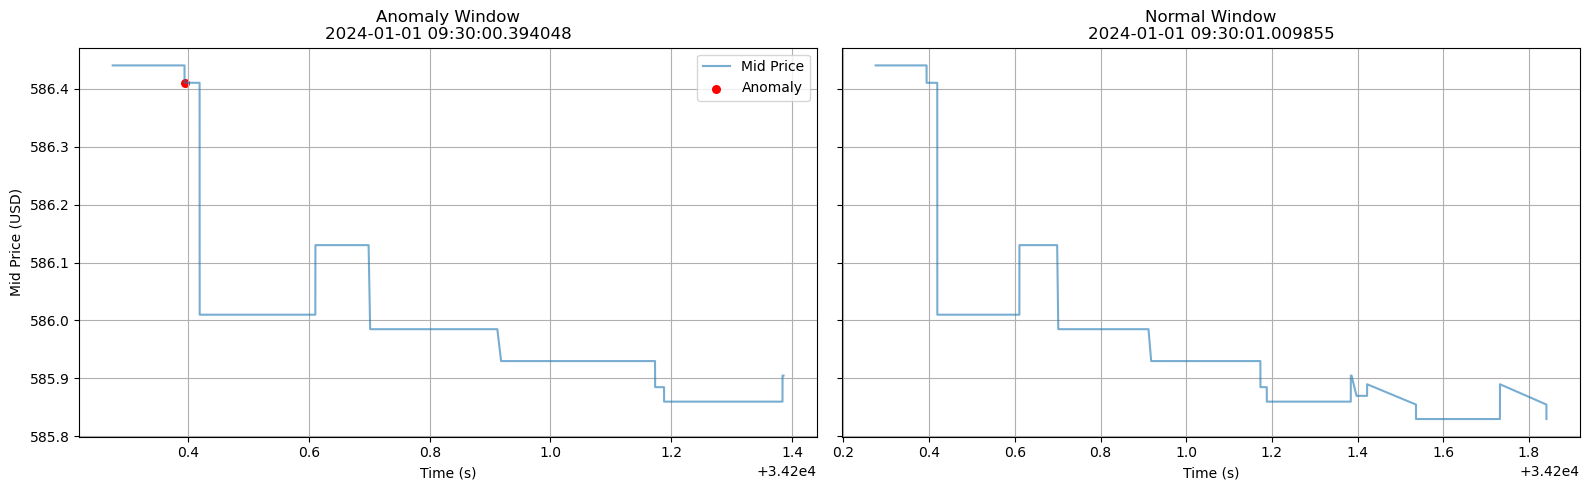

In [11]:
compare_anomaly_vs_normal(
    ts_anomaly='2024-01-01 09:30:00.394048',
    ts_normal='2024-01-01 09:30:01.009855',  # pick a  safe-looking timestamp
    window=1.0
)


Using OneClassSVM model on the data to compare with isolation forest    

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

# Use same features as before
X = df[feature_cols].dropna()

# Scale them — SVMs are sensitive to scale!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


+1 → normal
-1 → anomaly

In [13]:
ocsvm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')  # nu = proportion of outliers
df.loc[X.index, 'ocsvm_anomaly'] = ocsvm.fit_predict(X_scaled)


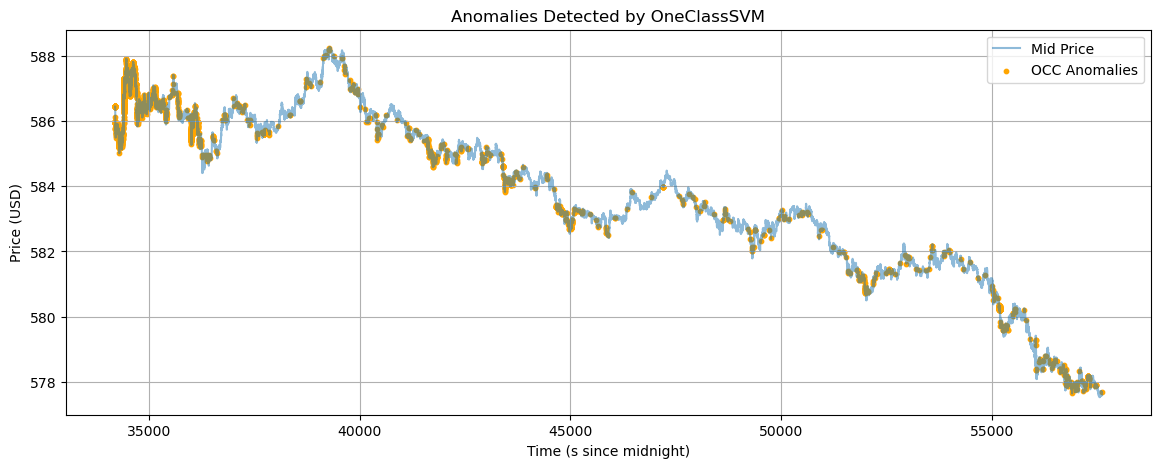

In [14]:
df['ocsvm_anomaly'] = df['ocsvm_anomaly'].astype(int)

plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['mid_price'], label='Mid Price', alpha=0.5)
plt.scatter(df[df['ocsvm_anomaly'] == -1]['time'],
            df[df['ocsvm_anomaly'] == -1]['mid_price'],
            color='orange', label='OCC Anomalies', s=10)
plt.title("Anomalies Detected by OneClassSVM")
plt.xlabel("Time (s since midnight)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from sklearn.metrics import confusion_matrix

# Optional: Compare where both agree
overlap = df[(df['anomaly'] == -1) & (df['ocsvm_anomaly'] == -1)]
print(f"Both models agree on {len(overlap)} anomalies.")


Both models agree on 391 anomalies.


With SVM, we can see the model is too sensitive and is clasifying a lot of anomalies.


Now implementing Autoencoders for anomaly detection. Autoencoder-style Anomaly Detection with PCA + Reconstruction Error (as kernel crashed)

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

feature_cols = ['spread', 'volume_imbalance', 'cancel_new_50', 'mid_price_diff']
X = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
#Dimensionality Reduction (like encoder)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_pca)


In [18]:
#Compute Reconstruction Error (like decoder loss)
mse = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)
df.loc[X.index, 'pca_mse'] = mse


In [19]:
#Flag Top 1% as Anomalies
threshold = np.percentile(mse, 99)  # top 1% are anomalies
df['pca_anomaly'] = (df['pca_mse'] > threshold).astype(int)


0    (normal points)
1    (anomalies)

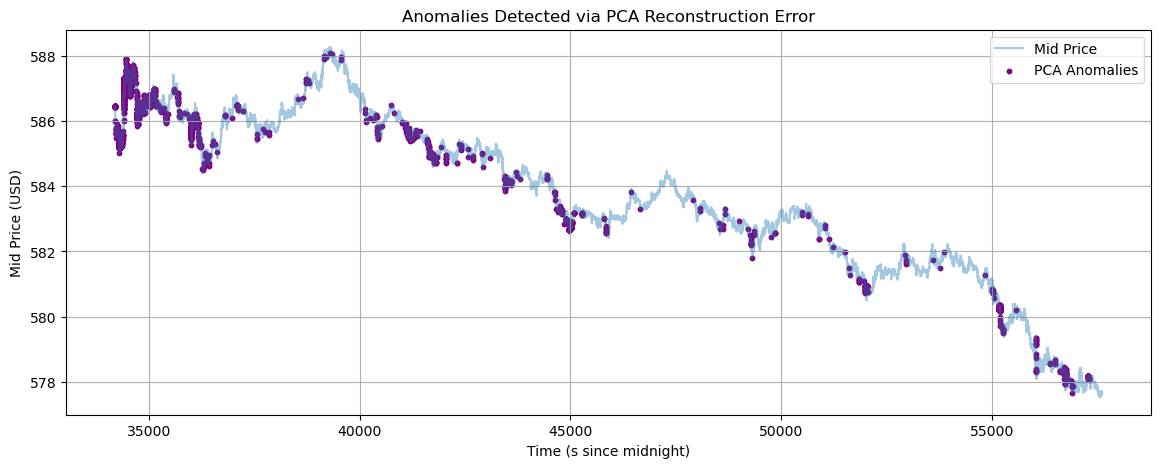

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['mid_price'], alpha=0.4, label='Mid Price')
plt.scatter(df[df['pca_anomaly'] == 1]['time'], df[df['pca_anomaly'] == 1]['mid_price'],
            color='purple', label='PCA Anomalies', s=10)
plt.title("Anomalies Detected via PCA Reconstruction Error")
plt.xlabel("Time (s since midnight)")
plt.ylabel("Mid Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
(df['ocsvm_anomaly'] == -1).sum()

4229

Now performing Feature clustering for better understanding.
Using only anomalies from isolation forest since they are real and strong outliers

In [26]:
anomalies = df[df['anomaly'] == -1].drop(columns='Unnamed: 0')

1)  KMeans Clustering
What It Does:
Partitions data into k groups based on distance to cluster centers.
Each cluster is a tight ball around a center point.
You must specify k upfront.

When to Use:
You expect clear, distinct types of anomalies.
Anomalies form separable groups (e.g., spoofing vs volume shocks).

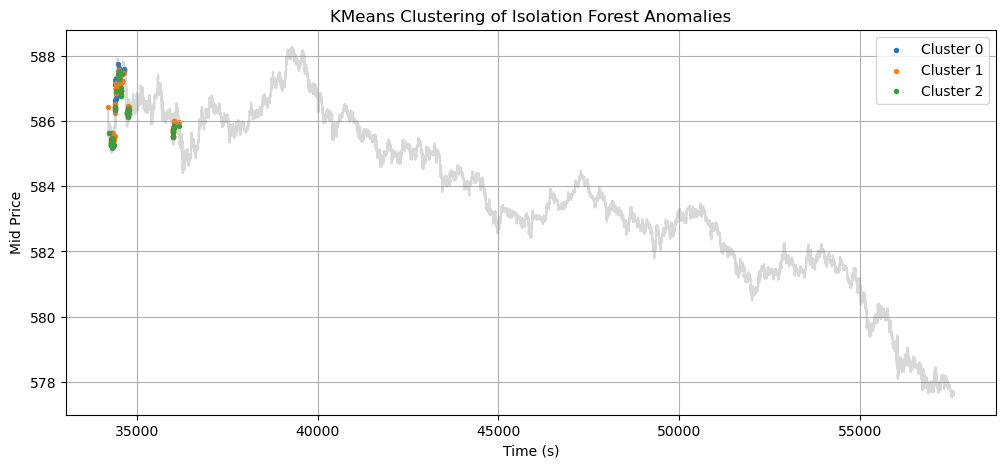

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
np.__config__.get_info('openblas')

features = ['spread', 'volume_imbalance', 'cancel_new_50', 'mid_price_diff']
X_cluster = anomalies[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
anomalies['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(12, 5))
for i in sorted(anomalies['kmeans_cluster'].unique()):
    sub = anomalies[anomalies['kmeans_cluster'] == i]
    plt.scatter(sub['time'], sub['mid_price'], s=8, label=f'Cluster {i}')
plt.plot(df['time'], df['mid_price'], color='gray', alpha=0.3)
plt.title("KMeans Clustering of Isolation Forest Anomalies")
plt.xlabel("Time (s)")
plt.ylabel("Mid Price")
plt.legend()
plt.grid(True)
plt.show()


2)  DBSCAN Clustering

What It Does:
- Groups points based on density (close neighbors).
- Automatically finds number of clusters and detects noise.
- It detects arbitrary-shaped clusters and leaves outliers as noise (Cluster -1).
- The number of clusters depends on parameters like eps (neighborhood radius) and min_samples.

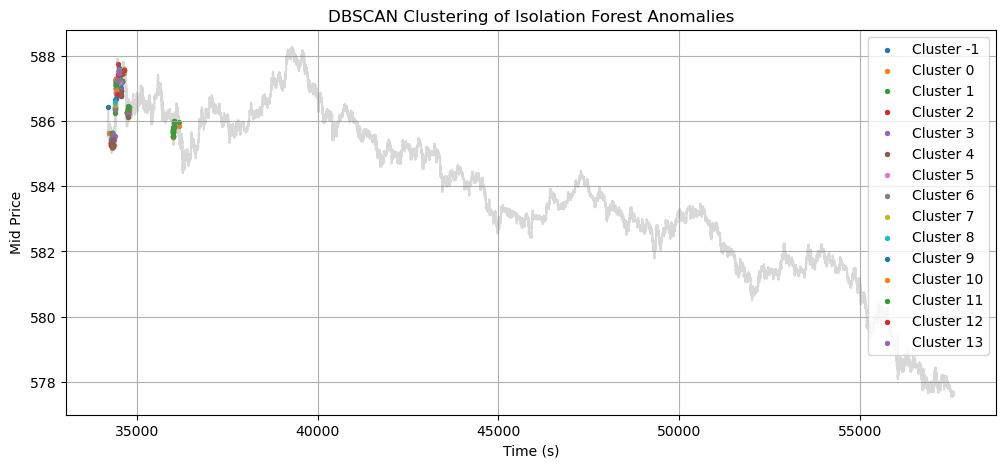

In [29]:
from sklearn.cluster import DBSCAN

# DBSCAN (no need to define number of clusters)
dbscan = DBSCAN(eps=0.7, min_samples=5)  # Try tweaking eps
anomalies['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(12, 5))
for i in sorted(anomalies['dbscan_cluster'].unique()):
    sub = anomalies[anomalies['dbscan_cluster'] == i]
    plt.scatter(sub['time'], sub['mid_price'], s=8, label=f'Cluster {i}')
plt.plot(df['time'], df['mid_price'], color='gray', alpha=0.3)
plt.title("DBSCAN Clustering of Isolation Forest Anomalies")
plt.xlabel("Time (s)")
plt.ylabel("Mid Price")
plt.legend()
plt.grid(True)
plt.show()


Recommendation for future:

- Use DBSCAN on the full dataset if you want to find both normal and anomalous behavioral regimes without assuming cluster shape.

- Use KMeans on the full dataset if you're looking for broader market segments or need fast, simple clustering.